In [1]:
import pandas as pd
import scanpy as sc
import plotnine as p9
import anndata as ad
import liana as li
import cell2cell as c2c
import decoupler as dc # needed for pathway enrichment

import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

%matplotlib inline

In [2]:
# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3             
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.9.6 anndata==0.10.4 umap==0.5.3 numpy==1.23.4 scipy==1.9.1 pandas==2.1.4 scikit-learn==1.2.0 statsmodels==0.14.1 igraph==0.10.8 pynndescent==0.5.8


## 1. Load & Prep Data

### 1.1 Showcase the processed anndata object

In [3]:
# read in SLE data in h5ad 
# it needs ~25G memory and several minutes
data_dir = '/home/qdai8/projects/Projects/STACCato/Data/SLE/processed/'
SLE_data_path = data_dir + 'GSE174188_basic_processed.h5ad'
adata = sc.read_h5ad(SLE_data_path)
subject_status = pd.read_csv(data_dir + 'subjects_status.txt', sep='\t')

In [4]:
subject_status = pd.read_csv(data_dir + 'subjects_status.txt', sep='\t')

In [5]:
adata

AnnData object with n_obs × n_vars = 1263480 × 25716
    obs: 'ind_cov', 'batch_cov', 'ind_cov_batch_cov', 'Processing_Cohort', 'Age', 'Sex', 'pop_cov', 'SLE_status', 'cg_cov', 'n_genes'
    var: 'gene_ids', 'feature_types-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Processing_Cohort_colors', 'SLE_status_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

### 1.2 Reduced the dataset down to one sequencing sample per subject

The SLE scRNA-seq dataset collects multiplexed scRNA-seq of 264 PBMC samples and 91 technical replicates from 162 SLE patients and 99 healthy controls. 355 sequencing samples = 264 samples + 91 replicates. 261 subjects = 162 SLE patients and 99 healthy controls.

In [6]:
adata.obs.ind_cov_batch_cov.nunique()

355

In [7]:
adata.obs.groupby('SLE_status')['ind_cov'].nunique()

SLE_status
Healthy     99
SLE        162
Name: ind_cov, dtype: int64

In [8]:
# Step 1: Extract the obs DataFrame
obs_df = adata.obs
# Step 2: Group by 'ind_cov' and 'batch_cov' and count the number of cells in each group
cell_counts = obs_df.groupby(['ind_cov', 'batch_cov']).size().reset_index(name='num_cells')
# Step 3: Identify the sample with the most cells for each subject
idx = cell_counts.groupby('ind_cov')['num_cells'].idxmax()
max_samples_per_subject = cell_counts.loc[idx]

array([[<Axes: title={'center': 'num_cells'}>]], dtype=object)

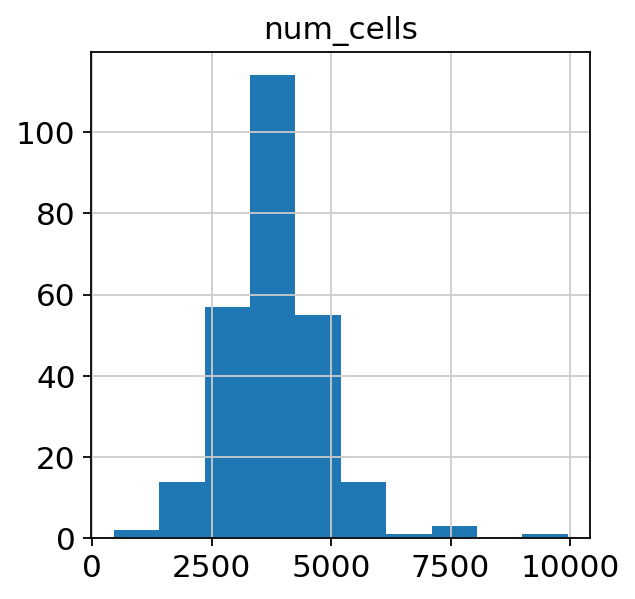

In [9]:
max_samples_per_subject.hist()

In [10]:
# Step 4: Filter the original AnnData object based on the selected samples
# First, create a boolean mask for the cells to keep
subject_sample_pairs = max_samples_per_subject.set_index(['ind_cov', 'batch_cov']).index
mask = adata.obs.set_index(['ind_cov', 'batch_cov']).index.isin(subject_sample_pairs)

In [11]:
# Apply the mask to filter the AnnData object
filtered_adata = adata[mask].copy()

In [12]:
filtered_adata

AnnData object with n_obs × n_vars = 1001419 × 25716
    obs: 'ind_cov', 'batch_cov', 'ind_cov_batch_cov', 'Processing_Cohort', 'Age', 'Sex', 'pop_cov', 'SLE_status', 'cg_cov', 'n_genes'
    var: 'gene_ids', 'feature_types-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Processing_Cohort_colors', 'SLE_status_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [13]:
filtered_adata.obs[['ind_cov', 'Processing_Cohort', 'SLE_status']].drop_duplicates().groupby(['SLE_status']).size()

SLE_status
Healthy     99
SLE        162
dtype: int64

In [14]:
# Add disease status and ancestry
merged_obs = filtered_adata.obs.merge(
    subject_status,
    on='ind_cov',  # or whatever column(s) to merge on
    how='left'     # left/inner/outer depending on your needs
)

# Update the obs
filtered_adata.obs = merged_obs

In [15]:
merged_obs

,ind_cov,batch_cov,ind_cov_batch_cov,Processing_Cohort,Age,Sex,pop_cov,SLE_status,cg_cov,n_genes,Status
0,HC-546,dmx_YS-JY-22_pool6,HC-546:dmx_YS-JY-22_pool6,4.0,28.0,Female,Asian,Healthy,T4,670,Healthy
1,FLARE006,dmx_AbFlare-3,FLARE006:dmx_AbFlare-3,3.0,34.0,Female,European,SLE,cM,1049,Flare
2,1479_1479,dmx_YE110,1479_1479:dmx_YE110,2.0,28.0,Female,Asian,SLE,T4,799,Managed
3,1333_1333,dmx_YS-JY-22_pool5,1333_1333:dmx_YS-JY-22_pool5,4.0,64.0,Female,Asian,SLE,T4,420,Managed
4,IGTB670_IGTB670,dmx_YE_7-13,IGTB670_IGTB670:dmx_YE_7-13,2.0,33.0,Female,European,Healthy,T4,608,Healthy
...,...,...,...,...,...,...,...,...,...,...,...
1001414,2132_2132,dmx_AbFlare-4,2132_2132:dmx_AbFlare-4,3.0,35.0,Male,European,SLE,NK,991,Flare
1001415,HC-554,dmx_YS-JY-22_pool6,HC-554:dmx_YS-JY-22_pool6,4.0,49.0,Female,European,Healthy,ncM,799,Healthy
1001416,IGTB1895_IGTB1895,dmx_count_AH7TNHDMXX_YE_8-30,IGTB1895_IGTB1895:dmx_count_AH7TNHDMXX_YE_8-30,1.0,27.0,Female,European,Healthy,cM,1516,Healthy
1001417,HC-526,dmx_YS-JY-20_pool4,HC-526:dmx_YS-JY-20_pool4,4.0,58.0,Female,European,Healthy,cM,759,Healthy


In [16]:
filtered_adata.obs[['ind_cov', 'Processing_Cohort', 'Status']].drop_duplicates().groupby(['Processing_Cohort', 'Status']).size()

Processing_Cohort  Status 
1.0                Flare        0
                   Healthy     42
                   Managed      0
                   Treated      0
2.0                Flare        0
                   Healthy      4
                   Managed    105
                   Treated      0
3.0                Flare       13
                   Healthy      9
                   Managed      1
                   Treated      3
4.0                Flare        0
                   Healthy     44
                   Managed     40
                   Treated      0
dtype: int64

### 1.5 Filter out AA / Hispanic samples

In [17]:
obs_df.drop_duplicates('ind_cov').reset_index(drop=True).value_counts('pop_cov')

pop_cov
European            149
Asian               107
African American      3
Hispanic              2
Name: count, dtype: int64

In [18]:
filtered_adata = filtered_adata[filtered_adata.obs.pop_cov.isin(['European', 'Asian']) & 
                                filtered_adata.obs.Status.isin(['Managed', 'Healthy'])] 

In [19]:
filtered_adata.obs[['ind_cov', 'Processing_Cohort', 'Status']].drop_duplicates().groupby(['Processing_Cohort', 'Status']).size()

Processing_Cohort  Status 
1.0                Healthy     42
                   Managed      0
2.0                Healthy      4
                   Managed    105
3.0                Healthy      8
                   Managed      1
4.0                Healthy     44
                   Managed     40
dtype: int64

In [20]:
filtered_adata.obs

,ind_cov,batch_cov,ind_cov_batch_cov,Processing_Cohort,Age,Sex,pop_cov,SLE_status,cg_cov,n_genes,Status
0,HC-546,dmx_YS-JY-22_pool6,HC-546:dmx_YS-JY-22_pool6,4.0,28.0,Female,Asian,Healthy,T4,670,Healthy
2,1479_1479,dmx_YE110,1479_1479:dmx_YE110,2.0,28.0,Female,Asian,SLE,T4,799,Managed
3,1333_1333,dmx_YS-JY-22_pool5,1333_1333:dmx_YS-JY-22_pool5,4.0,64.0,Female,Asian,SLE,T4,420,Managed
4,IGTB670_IGTB670,dmx_YE_7-13,IGTB670_IGTB670:dmx_YE_7-13,2.0,33.0,Female,European,Healthy,T4,608,Healthy
5,1368_1368,dmx_YE_8-2,1368_1368:dmx_YE_8-2,2.0,45.0,Male,European,SLE,T4,554,Managed
...,...,...,...,...,...,...,...,...,...,...,...
1001413,1615_1615,dmx_YE110,1615_1615:dmx_YE110,2.0,41.0,Male,European,SLE,cM,1228,Managed
1001415,HC-554,dmx_YS-JY-22_pool6,HC-554:dmx_YS-JY-22_pool6,4.0,49.0,Female,European,Healthy,ncM,799,Healthy
1001416,IGTB1895_IGTB1895,dmx_count_AH7TNHDMXX_YE_8-30,IGTB1895_IGTB1895:dmx_count_AH7TNHDMXX_YE_8-30,1.0,27.0,Female,European,Healthy,cM,1516,Healthy
1001417,HC-526,dmx_YS-JY-20_pool4,HC-526:dmx_YS-JY-20_pool4,4.0,58.0,Female,European,Healthy,cM,759,Healthy


In [21]:
filtered_adata.obs.index = filtered_adata.obs.index.astype(str)

mask = (
    filtered_adata.obs['pop_cov'].isin(['European', 'Asian']) & 
    filtered_adata.obs['Status'].isin(['Managed', 'Healthy']) &
    filtered_adata.obs['Processing_Cohort'].isin(['2.0', '4.0'])
)

# Then filter
filtered_adata = filtered_adata[mask].copy()

# Check result
print(filtered_adata.obs[['ind_cov', 'batch_cov']].drop_duplicates().shape[0])

193


In [22]:
filtered_adata.obs[['ind_cov', 'Processing_Cohort', 'Status']].drop_duplicates().groupby(['Processing_Cohort', 'Status']).size()

Processing_Cohort  Status 
2.0                Healthy      4
                   Managed    105
4.0                Healthy     44
                   Managed     40
dtype: int64

In [23]:
filtered_adata.obs.drop_duplicates(subset=['ind_cov', 'Processing_Cohort', 'Status', 'cg_cov']).groupby('cg_cov').size()

cg_cov
B         191
NK        193
PB        152
Progen    158
Prolif    192
T4        193
T8        193
cDC       193
cM        193
ncM       193
pDC       192
dtype: int64

## 2. Ligand-Receptor Inference by Sample

In [24]:
sample_key = 'ind_cov'
condition_key = 'SLE_status'
groupby = 'cg_cov'

In [25]:
li.mt.rank_aggregate.by_sample(
    filtered_adata,
    groupby=groupby,
    resource_name='consensus', # NOTE: uses human gene symbols!
    sample_key=sample_key, # sample key by which we which to loop
    use_raw=False,
    verbose=True, # use 'full' to show all verbose information
    n_perms=None, # exclude permutations for speed
    return_all_lrs=True, # return all LR values
    )

Converting `ind_cov` to categorical!
Now running: 1004_1004:   0%|                                                      | 0/193 [00:00<?, ?it/s]

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


Now running: 1014_1014:   1%|▏                                             | 1/193 [00:09<31:09,  9.74s/it]

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


Now running: 1015_1015:   1%|▍                                             | 2/193 [00:21<34:02, 10.69s/it]

...

Now running: IGTB1542_IGTB1542:  99%|███████████████████████████████████▋| 191/193 [33:41<00:20, 10.39s/it]

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


Now running: IGTB670_IGTB670:  99%|█████████████████████████████████████▊| 192/193 [33:51<00:10, 10.24s/it]

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


Now running: IGTB670_IGTB670: 100%|██████████████████████████████████████| 193/193 [34:07<00:00, 10.61s/it]


In [26]:
filtered_adata.uns["liana_res"].sort_values("magnitude_rank").head(10)

,ind_cov,source,target,ligand_complex,receptor_complex,lr_means,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,lr_probs,magnitude_rank
10111389,1420_1420,NK,Prolif,B2M,CD3D,2.713690,5.405909,1.237455,0.903067,0.040807,0.982097,0.239810,7.975829e-15
16699383,1772_1772,NK,Prolif,B2M,CD3D,2.736618,5.171165,1.213737,0.840330,0.035669,0.981948,0.176755,1.240019e-14
26088278,IGTB670_IGTB670,NK,T8,B2M,CD3D,2.326098,3.106772,1.211648,0.709148,0.029864,0.977447,0.152565,1.356064e-14
13429181,1615_1615,NK,Prolif,B2M,CD3D,2.500787,3.849184,1.214405,0.767220,0.034716,0.978882,0.173935,1.366007e-14
23284610,HC-541,NK,Prolif,B2M,CD3D,2.797743,6.141173,1.452751,1.072094,0.040994,0.983001,0.209019,1.377068e-14
18315227,1857_1857,NK,T8,B2M,CD3D,2.771051,5.030714,1.060357,0.840771,0.033103,0.980678,0.177891,1.379133e-14
2035680,1068_1068,NK,Prolif,B2M,CD3D,2.465672,4.538223,1.052631,0.643215,0.032742,0.980051,0.213125,1.771946e-14
20153580,2135_2135,NK,T8,B2M,CD3D,2.695768,4.738609,1.235345,1.029368,0.035556,0.980968,0.166538,1.781771e-14
8021435,1325_1325,NK,Prolif,B2M,CD3D,2.622602,4.421525,0.922151,0.706959,0.034764,0.980497,0.163563,1.894842e-14
1672680,1056_1056,NK,T8,B2M,CD3D,2.625287,4.572207,1.262498,0.963968,0.039471,0.978259,0.198000,1.899118e-14


In [27]:
filtered_adata.uns["liana_res"].ind_cov.value_counts()

ind_cov
1420_1420          248776
1087_1087          234619
1772_1772          214654
IGTB670_IGTB670    207878
HC-541             207757
                    ...  
ICC_control         80271
HC-019              77193
HC-574              69120
HC-008              60662
HC-566              11225
Name: count, Length: 193, dtype: int64

In [28]:
import os
out_dir = '/home/qdai8/projects/Projects/STACCato/Results/SLE/LIANA/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [29]:
filtered_adata.write_h5ad(out_dir + "liana_res.h5ad")

... storing 'Status' as categorical


## 3. Build Tensor

- expr_prod, outer_cells

In [30]:
tensor = li.multi.to_tensor_c2c(filtered_adata,
                                sample_key=sample_key,
                                score_key='expr_prod', # can be any score from liana
                                how='outer_cells',
                                outer_fraction=0.8)

100%|████████████████████████████████████████████████████████████████████| 193/193 [11:47<00:00,  3.66s/it]


In [31]:
import os
sub_out_dir = out_dir + 'expr_prod_outer_cells'
if not os.path.exists(sub_out_dir):
    os.makedirs(sub_out_dir)

In [32]:
from scipy.io import savemat
mymat={'c2ctensor':tensor.tensor}
savemat(sub_out_dir + "/c2ctensor.mat", mymat)

pd.DataFrame(tensor.order_names[1]).to_csv(sub_out_dir + '/lr.txt', 
                      mode='w',
                      index=None,
                      header=None,
                      sep='\t')

pd.DataFrame(tensor.order_names[2]).to_csv(sub_out_dir + '/sender.txt', 
                      mode='w',
                      index=None,
                      header=None,
                      sep='\t')

pd.DataFrame(tensor.order_names[3]).to_csv(sub_out_dir + '/receiver.txt', 
                      mode='w',
                      index=None,
                      header=None,
                      sep='\t')

In [33]:
subjects = tensor.order_names[0]
out_cols = ['ind_cov', 'batch_cov', 'ind_cov_batch_cov', 'Processing_Cohort', 'Age', 'Sex', 'pop_cov', 'SLE_status']
subject_info = filtered_adata.obs[out_cols].drop_duplicates().reset_index(drop=True)


# Step 1: Create a mapping from list values to order indices
order_mapping = {value: index for index, value in enumerate(subjects)}
# Step 2: Map the 'cov_ind' column to order indices
subject_info['order'] = subject_info['ind_cov'].map(order_mapping)
# Step 3: Sort the DataFrame based on the 'order' column
subject_info = subject_info.sort_values('order').drop(columns='order').reset_index(drop=True)

subject_info.to_csv(sub_out_dir + '/subjects_info.txt', 
                    mode='w',
                    index=None,
                    header=True,
                    sep='\t')

In [34]:
# Results saved to perform Tensor-cell2cell
context_dict = filtered_adata.obs.sort_values(by='ind_cov') \
                        .set_index('ind_cov')['SLE_status'] \
                        .to_dict()

dimensions_dict = [context_dict, None, None, None]
meta_tensor = c2c.tensor.generate_tensor_metadata(interaction_tensor=tensor,
                                                  metadata_dicts=dimensions_dict,
                                                  fill_with_order_elements=True
                                                 )

c2c.io.export_variable_with_pickle(variable=tensor,
                                   filename=sub_out_dir + '/Tensor.pkl')
c2c.io.export_variable_with_pickle(variable=meta_tensor,
                                   filename=sub_out_dir + '/Tensor-Metadata.pkl')

/home/qdai8/projects/Projects/STACCato/Results/SLE/LIANA/expr_prod_outer_cells/Tensor.pkl  was correctly saved.
/home/qdai8/projects/Projects/STACCato/Results/SLE/LIANA/expr_prod_outer_cells/Tensor-Metadata.pkl  was correctly saved.


- expr_prod, outer_both

In [35]:
tensor = li.multi.to_tensor_c2c(filtered_adata,
                                sample_key=sample_key,
                                score_key='expr_prod', # can be any score from liana
                                how='outer',
                                outer_fraction=0.8)

100%|████████████████████████████████████████████████████████████████████| 193/193 [34:06<00:00, 10.60s/it]


In [36]:
import os
sub_out_dir = out_dir + 'expr_prod_outer_both'
if not os.path.exists(sub_out_dir):
    os.makedirs(sub_out_dir)

In [37]:
from scipy.io import savemat
mymat={'c2ctensor':tensor.tensor}
savemat(sub_out_dir + "c2ctensor.mat", mymat)

pd.DataFrame(tensor.order_names[1]).to_csv(sub_out_dir + '/lr.txt', 
                      mode='w',
                      index=None,
                      header=None,
                      sep='\t')

pd.DataFrame(tensor.order_names[2]).to_csv(sub_out_dir + '/sender.txt', 
                      mode='w',
                      index=None,
                      header=None,
                      sep='\t')

pd.DataFrame(tensor.order_names[3]).to_csv(sub_out_dir + '/receiver.txt', 
                      mode='w',
                      index=None,
                      header=None,
                      sep='\t')

In [38]:
subjects = tensor.order_names[0]
out_cols = ['ind_cov', 'batch_cov', 'ind_cov_batch_cov', 'Processing_Cohort', 'Age', 'Sex', 'pop_cov', 'SLE_status']
subject_info = filtered_adata.obs[out_cols].drop_duplicates().reset_index(drop=True)


# Step 1: Create a mapping from list values to order indices
order_mapping = {value: index for index, value in enumerate(subjects)}
# Step 2: Map the 'cov_ind' column to order indices
subject_info['order'] = subject_info['ind_cov'].map(order_mapping)
# Step 3: Sort the DataFrame based on the 'order' column
subject_info = subject_info.sort_values('order').drop(columns='order').reset_index(drop=True)

subject_info.to_csv(sub_out_dir + '/subjects_info.txt', 
                    mode='w',
                    index=None,
                    header=True,
                    sep='\t')

In [39]:
# Results saved to perform Tensor-cell2cell
context_dict = filtered_adata.obs.sort_values(by='ind_cov') \
                        .set_index('ind_cov')['SLE_status'] \
                        .to_dict()

dimensions_dict = [context_dict, None, None, None]
meta_tensor = c2c.tensor.generate_tensor_metadata(interaction_tensor=tensor,
                                                  metadata_dicts=dimensions_dict,
                                                  fill_with_order_elements=True
                                                 )

c2c.io.export_variable_with_pickle(variable=tensor,
                                   filename=sub_out_dir + '/Tensor.pkl')
c2c.io.export_variable_with_pickle(variable=meta_tensor,
                                   filename=sub_out_dir + '/Tensor-Metadata.pkl')

/home/qdai8/projects/Projects/STACCato/Results/SLE/LIANA/expr_prod_outer_both/Tensor.pkl  was correctly saved.
/home/qdai8/projects/Projects/STACCato/Results/SLE/LIANA/expr_prod_outer_both/Tensor-Metadata.pkl  was correctly saved.
